In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc file CSV
# parse_dates: Tự động hiểu cột Datetime là thời gian
df = pd.read_csv('../../data/raw/data_price_realtime.csv', parse_dates=['Datetime'])

# 2. Đặt Datetime làm Index (Rất quan trọng cho Time-series)
df.set_index('Datetime', inplace=True)

# 3. Sắp xếp lại thời gian (đề phòng gói tin Socket đến lộn xộn)
df.sort_index(inplace=True)

print("Dữ liệu thô ban đầu:")
print(df.head(5))
# Lúc này bạn sẽ thấy rất nhiều giá trị NaN (Not a Number)

Dữ liệu thô ban đầu:
                        Gold   Silver    Brent     Wheat  USD index
Datetime                                                           
2025-11-28 09:54:10  4189.25      NaN      NaN       NaN        NaN
2025-11-28 09:54:10  4189.25  54.0125      NaN       NaN        NaN
2025-11-28 09:54:10  4189.25  54.0125  62.8905       NaN        NaN
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042        NaN
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042    0.80531


In [2]:
# 1. Forward Fill: Lấp đầy ô trống bằng giá trị liền trước nó
df_clean = df.ffill()

# 2. Backward Fill (Tùy chọn):
# Xử lý các dòng đầu tiên nếu dòng 1 chưa có dữ liệu ngay
# Lưu ý: Chỉ dùng bfill cho vài dòng đầu, lạm dụng sẽ gây Data Leakage (lộ đề)
df_clean = df_clean.bfill()

print("Dữ liệu sau khi lấp đầy:")
print(df_clean.head(5))

Dữ liệu sau khi lấp đầy:
                        Gold   Silver    Brent     Wheat  USD index
Datetime                                                           
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042    0.80531
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042    0.80531
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042    0.80531
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042    0.80531
2025-11-28 09:54:10  4189.25  54.0125  62.8905  522.0042    0.80531


In [3]:
# Resample về khung thời gian 1 phút (1min) hoặc 5 phút (5min)
# .last(): Lấy giá trị cuối cùng trong phút đó (Close Price)
df_resampled = df_clean.resample('10s').last()

# Sau khi resample, có thể lại sinh ra NaN (phút đó không có giao dịch)
# Ta lại ffill một lần nữa cho chắc
df_resampled = df_resampled.ffill()

# Xóa các dòng NaN còn sót lại (nếu có)
df_resampled.dropna(inplace=True)

print(f"Kích thước dữ liệu chuẩn để train: {df_resampled.shape}")

Kích thước dữ liệu chuẩn để train: (177862, 5)


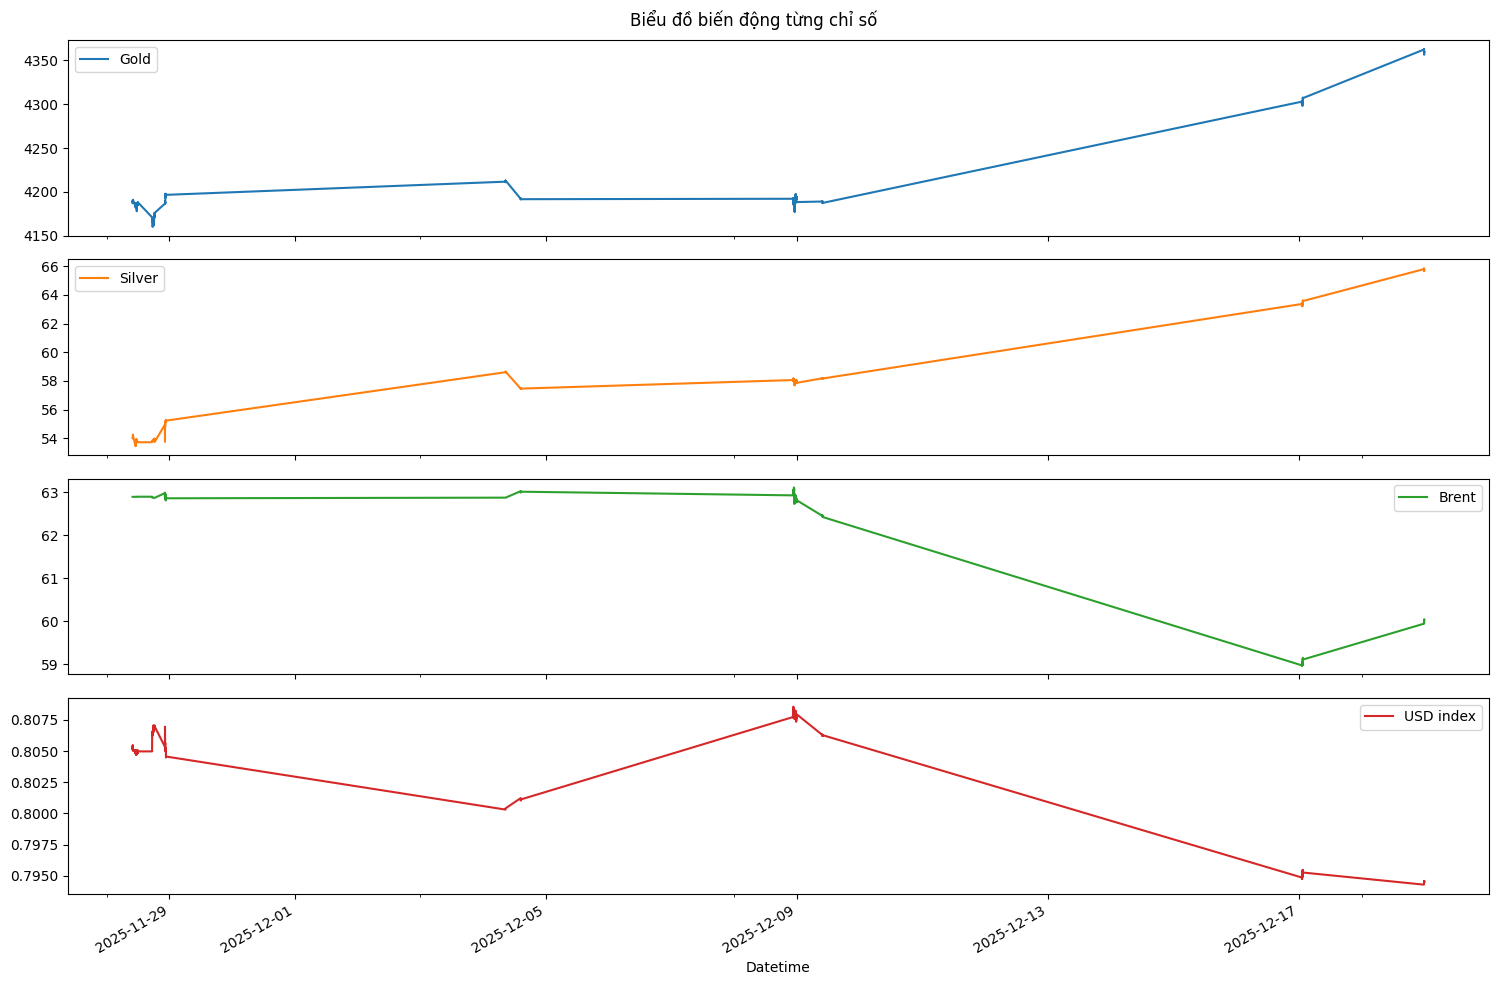

In [4]:
import matplotlib.pyplot as plt

# Vẽ các cột quan trọng trên các biểu đồ con riêng biệt
cols_to_plot = ['Gold', 'Silver', 'Brent', 'USD index']
df_clean[cols_to_plot].plot(subplots=True, figsize=(15, 10), title="Biểu đồ biến động từng chỉ số")
plt.tight_layout()
plt.show()

In [5]:
# Xuất file cuối cùng để ném vào Model
df_resampled.to_csv('../../data/processed/training_price_final.csv')
print("✅ Đã xuất file training_price_final.csv thành công!")

✅ Đã xuất file training_price_final.csv thành công!
